In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import classification_report,confusion_matrix,f1_score,accuracy_score,roc_auc_score,precision_score,recall_score

1.  load data and basic information 

In [2]:
df=pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\python\Machine learning\Decision_Tree\dynamic_supply_chain_logistics_dataset.csv")
df

,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,...,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,...,0.574400,0.777263,1.182116,0.502006,0.033843,0.978599,0.506152,0.885291,Moderate Risk,9.110682
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,...,-9.753493,0.091839,9.611988,0.966774,0.201725,0.918586,0.980784,0.544178,High Risk,8.175281
2,2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,...,-6.491034,0.253529,6.570431,0.945627,0.264045,0.394215,0.998633,0.803322,High Risk,1.283594
3,2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,...,-0.151276,0.877576,0.548952,4.674035,0.362885,0.905444,0.993320,0.025977,High Risk,9.304897
4,2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,...,2.429448,0.262081,8.861443,3.445429,0.016957,0.258702,0.912433,0.991122,High Risk,7.752484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32060,2024-08-28 20:00:00,48.496665,-104.031158,5.421806,4.394370,0.192421,127.684977,3.607803,0.208643,0.992997,...,-8.835069,0.199377,9.893402,0.966050,0.109571,0.511074,0.953467,0.916745,High Risk,5.506049
32061,2024-08-28 21:00:00,34.670137,-89.893091,10.624778,2.700635,8.736143,84.638889,1.218165,0.472389,0.946031,...,-2.517654,0.673775,0.854378,1.665889,0.530289,0.868418,0.995329,0.808963,High Risk,-1.876938
32062,2024-08-28 22:00:00,42.963338,-82.149873,5.071596,0.485288,7.420200,48.500920,4.999149,0.064366,0.437687,...,29.410878,0.949644,4.480552,0.690990,0.537100,0.896798,0.442299,0.959197,Moderate Risk,9.790219
32063,2024-08-28 23:00:00,32.082410,-70.070154,5.000000,4.759411,0.932050,972.437425,0.505242,0.250949,0.517051,...,-6.951137,0.407377,9.185549,4.462204,0.012896,0.463018,0.999999,0.557340,High Risk,9.956879


In [3]:
df.head(10)

,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,...,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,...,0.574400,0.777263,1.182116,0.502006,0.033843,0.978599,0.506152,0.885291,Moderate Risk,9.110682
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,...,-9.753493,0.091839,9.611988,0.966774,0.201725,0.918586,0.980784,0.544178,High Risk,8.175281
2,2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,...,-6.491034,0.253529,6.570431,0.945627,0.264045,0.394215,0.998633,0.803322,High Risk,1.283594
3,2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,...,-0.151276,0.877576,0.548952,4.674035,0.362885,0.905444,0.993320,0.025977,High Risk,9.304897
4,2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,...,2.429448,0.262081,8.861443,3.445429,0.016957,0.258702,0.912433,0.991122,High Risk,7.752484
5,2021-01-01 05:00:00,47.864549,-119.998386,5.533563,4.862386,0.499405,822.590649,0.768521,0.062074,0.397323,...,11.301343,0.041378,9.492603,2.163846,0.183964,0.978620,0.838287,0.982023,High Risk,-1.630307
6,2021-01-01 06:00:00,33.846390,-95.940118,5.779804,4.999979,8.750501,6.048354,3.923828,0.333237,0.002689,...,-9.076670,0.243348,9.870430,4.159665,0.020699,0.986597,0.999357,0.061457,High Risk,5.135374
7,2021-01-01 07:00:00,32.601885,-102.316635,5.474695,0.375511,4.813078,256.293208,2.352963,0.021812,0.240859,...,36.838728,0.344496,2.954216,1.456898,0.012490,0.185078,0.514001,0.979538,Moderate Risk,7.432758
8,2021-01-01 08:00:00,39.787194,-90.897918,5.680607,4.958875,9.613161,109.816868,0.592249,0.049304,0.183048,...,-9.999960,0.914129,7.158868,2.169863,0.876879,0.996431,0.321267,0.223533,Moderate Risk,1.323351
9,2021-01-01 09:00:00,47.728499,-113.413561,5.088425,1.508709,9.897407,0.032110,0.781215,0.069873,0.744814,...,-10.000000,0.032444,3.587067,3.751473,0.011959,0.453395,0.996365,0.233778,High Risk,0.739935


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32065 entries, 0 to 32064
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   timestamp                        32065 non-null  str    
 1   vehicle_gps_latitude             32065 non-null  float64
 2   vehicle_gps_longitude            32065 non-null  float64
 3   fuel_consumption_rate            32065 non-null  float64
 4   eta_variation_hours              32065 non-null  float64
 5   traffic_congestion_level         32065 non-null  float64
 6   warehouse_inventory_level        32065 non-null  float64
 7   loading_unloading_time           32065 non-null  float64
 8   handling_equipment_availability  32065 non-null  float64
 9   order_fulfillment_status         32065 non-null  float64
 10  weather_condition_severity       32065 non-null  float64
 11  port_congestion_level            32065 non-null  float64
 12  shipping_costs               

In [5]:
df.isnull().sum().sum()

np.int64(0)

In [6]:
df.columns.tolist()

['timestamp',
 'vehicle_gps_latitude',
 'vehicle_gps_longitude',
 'fuel_consumption_rate',
 'eta_variation_hours',
 'traffic_congestion_level',
 'warehouse_inventory_level',
 'loading_unloading_time',
 'handling_equipment_availability',
 'order_fulfillment_status',
 'weather_condition_severity',
 'port_congestion_level',
 'shipping_costs',
 'supplier_reliability_score',
 'lead_time_days',
 'historical_demand',
 'iot_temperature',
 'cargo_condition_status',
 'route_risk_level',
 'customs_clearance_time',
 'driver_behavior_score',
 'fatigue_monitoring_score',
 'disruption_likelihood_score',
 'delay_probability',
 'risk_classification',
 'delivery_time_deviation']

In [7]:
# convert time stamp to datetime
df['timestamp']=pd.to_datetime(df['timestamp'])
df['timestamp']

0       2021-01-01 00:00:00
1       2021-01-01 01:00:00
2       2021-01-01 02:00:00
3       2021-01-01 03:00:00
4       2021-01-01 04:00:00
                ...        
32060   2024-08-28 20:00:00
32061   2024-08-28 21:00:00
32062   2024-08-28 22:00:00
32063   2024-08-28 23:00:00
32064   2024-08-29 00:00:00
Name: timestamp, Length: 32065, dtype: datetime64[us]

In [8]:
# min time stamp
df['timestamp'].min()

Timestamp('2021-01-01 00:00:00')

In [9]:
# max time stamp.max
df['timestamp'].max()

Timestamp('2024-08-29 00:00:00')

In [10]:
df

,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,...,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,...,0.574400,0.777263,1.182116,0.502006,0.033843,0.978599,0.506152,0.885291,Moderate Risk,9.110682
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,...,-9.753493,0.091839,9.611988,0.966774,0.201725,0.918586,0.980784,0.544178,High Risk,8.175281
2,2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,...,-6.491034,0.253529,6.570431,0.945627,0.264045,0.394215,0.998633,0.803322,High Risk,1.283594
3,2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,...,-0.151276,0.877576,0.548952,4.674035,0.362885,0.905444,0.993320,0.025977,High Risk,9.304897
4,2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,...,2.429448,0.262081,8.861443,3.445429,0.016957,0.258702,0.912433,0.991122,High Risk,7.752484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32060,2024-08-28 20:00:00,48.496665,-104.031158,5.421806,4.394370,0.192421,127.684977,3.607803,0.208643,0.992997,...,-8.835069,0.199377,9.893402,0.966050,0.109571,0.511074,0.953467,0.916745,High Risk,5.506049
32061,2024-08-28 21:00:00,34.670137,-89.893091,10.624778,2.700635,8.736143,84.638889,1.218165,0.472389,0.946031,...,-2.517654,0.673775,0.854378,1.665889,0.530289,0.868418,0.995329,0.808963,High Risk,-1.876938
32062,2024-08-28 22:00:00,42.963338,-82.149873,5.071596,0.485288,7.420200,48.500920,4.999149,0.064366,0.437687,...,29.410878,0.949644,4.480552,0.690990,0.537100,0.896798,0.442299,0.959197,Moderate Risk,9.790219
32063,2024-08-28 23:00:00,32.082410,-70.070154,5.000000,4.759411,0.932050,972.437425,0.505242,0.250949,0.517051,...,-6.951137,0.407377,9.185549,4.462204,0.012896,0.463018,0.999999,0.557340,High Risk,9.956879


2. Risk Classification Analysis

In [11]:
# unique risk classes
print("Unique risk classes :",df['risk_classification'].nunique())

Unique risk classes : 3


In [12]:
print("class distribution count :",df['risk_classification'].value_counts())

class distribution count : risk_classification
High Risk        23944
Moderate Risk     5011
Low Risk          3110
Name: count, dtype: int64


In [13]:

print("\nClass Distribution (Percentage):")
df['risk_classification'].value_counts(normalize=True).mul(100).round(2)


Class Distribution (Percentage):


risk_classification
High Risk        74.67
Moderate Risk    15.63
Low Risk          9.70
Name: proportion, dtype: float64

3. Delivery Time Deviation Stats

In [14]:
df['delivery_time_deviation'].describe().round(3)

count    32065.000
mean         5.178
std          4.158
min         -2.000
25%          1.269
50%          6.114
75%          9.249
max         10.000
Name: delivery_time_deviation, dtype: float64

4. Missing Values Check

In [15]:
df.isnull().sum().sum()

np.int64(0)

In [16]:
df.duplicated().sum()

np.int64(0)

5. Time-Series Continuity Check

In [17]:
df=df.sort_values('timestamp').reset_index(drop=True)
df_indexed =df.set_index('timestamp')
df_indexed

,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,...,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
timestamp,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,0.359066,...,0.574400,0.777263,1.182116,0.502006,0.033843,0.978599,0.506152,0.885291,Moderate Risk,9.110682
2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,0.230660,...,-9.753493,0.091839,9.611988,0.966774,0.201725,0.918586,0.980784,0.544178,High Risk,8.175281
2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,0.027210,...,-6.491034,0.253529,6.570431,0.945627,0.264045,0.394215,0.998633,0.803322,High Risk,1.283594
2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,0.616619,...,-0.151276,0.877576,0.548952,4.674035,0.362885,0.905444,0.993320,0.025977,High Risk,9.304897
2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,0.952385,...,2.429448,0.262081,8.861443,3.445429,0.016957,0.258702,0.912433,0.991122,High Risk,7.752484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-28 20:00:00,48.496665,-104.031158,5.421806,4.394370,0.192421,127.684977,3.607803,0.208643,0.992997,0.792648,...,-8.835069,0.199377,9.893402,0.966050,0.109571,0.511074,0.953467,0.916745,High Risk,5.506049
2024-08-28 21:00:00,34.670137,-89.893091,10.624778,2.700635,8.736143,84.638889,1.218165,0.472389,0.946031,0.034156,...,-2.517654,0.673775,0.854378,1.665889,0.530289,0.868418,0.995329,0.808963,High Risk,-1.876938
2024-08-28 22:00:00,42.963338,-82.149873,5.071596,0.485288,7.420200,48.500920,4.999149,0.064366,0.437687,0.022338,...,29.410878,0.949644,4.480552,0.690990,0.537100,0.896798,0.442299,0.959197,Moderate Risk,9.790219


In [18]:
df['time_diff_hours']=df['timestamp'].diff().dt.total_seconds()/3600
df['time_diff_hours']

0        NaN
1        1.0
2        1.0
3        1.0
4        1.0
        ... 
32060    1.0
32061    1.0
32062    1.0
32063    1.0
32064    1.0
Name: time_diff_hours, Length: 32065, dtype: float64

In [19]:
print("Time Difference Value Counts:")
print(df['time_diff_hours'].value_counts().head())

Time Difference Value Counts:
time_diff_hours
1.0    32064
Name: count, dtype: int64


In [20]:
print("Number of Gaps > 1 Hour:",
      (df['time_diff_hours'] > 1).sum())

Number of Gaps > 1 Hour: 0


In [21]:
print("Minimum Time Difference:",
      df['time_diff_hours'].min())

Minimum Time Difference: 1.0


In [22]:
print("Maximum Time Difference:",
      df['time_diff_hours'].max())

Maximum Time Difference: 1.0


6. Status Columns Analysis

In [23]:
df['order_fulfillment_status'].dtype

dtype('float64')

In [24]:
# uniue value
print("Unique Values:", df['order_fulfillment_status'].nunique())


Unique Values: 32065


In [25]:
# Sample Distribution (%)
print("sample distribution %",df['order_fulfillment_status'].value_counts(normalize=True).head().mul(100).round(2))


sample distribution % order_fulfillment_status
0.761166    0.0
0.196594    0.0
0.152742    0.0
0.811885    0.0
0.053659    0.0
Name: proportion, dtype: float64


In [26]:
# Cargo Condition Status
df['cargo_condition_status'].dtype

dtype('float64')

In [27]:
print("Unique Values:", df['cargo_condition_status'].nunique())

Unique Values: 32065


In [28]:
print("Sample Distribution (%):")
print(df['cargo_condition_status'].value_counts(normalize=True).head().mul(100).round(2))

Sample Distribution (%):
cargo_condition_status
0.777263    0.0
0.091839    0.0
0.253529    0.0
0.877576    0.0
0.262081    0.0
Name: proportion, dtype: float64


Data Cleaning & Preprocessing 

7. Outlier Detection & Clipping

In [29]:
# numerical range check clipping

cols=['fuel_consumption_rate','eta_variation_hours','iot_temperature']

print("Before clipping (Min/Max):")
print(df[cols].describe().loc[['min', 'max']].round(3))

Before clipping (Min/Max):
     fuel_consumption_rate  eta_variation_hours  iot_temperature
min                    5.0                 -2.0            -10.0
max                   20.0                  5.0             40.0


In [30]:
# Apply clipping

df['fuel_consumption_rate'] = df['fuel_consumption_rate'].clip(0, 25)
df['eta_variation_hours']   = df['eta_variation_hours'].clip(-24, 24)
df['iot_temperature']       = df['iot_temperature'].clip(-50, 60)

In [31]:
print("\nAfter Clipping (Min/Max):")
print(df[cols].describe().loc[['min', 'max']].round(3))


After Clipping (Min/Max):
     fuel_consumption_rate  eta_variation_hours  iot_temperature
min                    5.0                 -2.0            -10.0
max                   20.0                  5.0             40.0


8. Negative Delivery Deviation

In [32]:
negative_percentage = (df['delivery_time_deviation'] < 0).mean() * 100
negative_count = (df['delivery_time_deviation'] < 0).sum()

In [33]:

print(f"Percentage of Early Deliveries: {negative_percentage:.2f}%")
print("Total Early Deliveries:", negative_count)

Percentage of Early Deliveries: 17.91%
Total Early Deliveries: 5742


In [34]:
# Business Features
df['is_early'] = df['delivery_time_deviation']<0
df['deviation_magnitude'] = df['delivery_time_deviation'].abs()

9. Ordinal Encoding (Risk)

In [35]:

risk_map = {
    'Low Risk': 0,
    'Moderate Risk': 1,
    'High Risk': 2
}
df['risk_encoded'] = df['risk_classification'].map(risk_map)

In [36]:

print(df[['risk_classification', 'risk_encoded']].head())

  risk_classification  risk_encoded
0       Moderate Risk             1
1           High Risk             2
2           High Risk             2
3           High Risk             2
4           High Risk             2


In [37]:
print("Encoded Value Counts:\n",df['risk_encoded'].value_counts())

Encoded Value Counts:
 risk_encoded
2    23944
1     5011
0     3110
Name: count, dtype: int64


10. Distance Proxy Feature

In [38]:

df['lat_diff'] = df['vehicle_gps_latitude'].diff().abs()
df['lon_diff'] = df['vehicle_gps_longitude'].diff().abs()

In [39]:
df['distance_proxy'] = df['lat_diff'] + df['lon_diff']

In [40]:
print(df[['timestamp', 'distance_proxy']].head(10))
print("\nAverage Distance Proxy per Hour:",
      round(df['distance_proxy'].mean(), 4))

            timestamp  distance_proxy
0 2021-01-01 00:00:00             NaN
1 2021-01-01 01:00:00       46.890335
2 2021-01-01 02:00:00       45.254857
3 2021-01-01 03:00:00       11.707277
4 2021-01-01 04:00:00        6.826278
5 2021-01-01 05:00:00       67.849461
6 2021-01-01 06:00:00       38.076427
7 2021-01-01 07:00:00        7.621023
8 2021-01-01 08:00:00       18.604026
9 2021-01-01 09:00:00       30.456947

Average Distance Proxy per Hour: 27.4869


11.Duplicate Row Check

In [41]:
duplicate_count=df.duplicated().sum()
duplicate_count

np.int64(0)

In [42]:
df.shape


(32065, 33)

12 Time-Based Feature Engineering

In [43]:
df['hour_of_day']=df['timestamp'].dt.hour
df['is_weekend']=df['timestamp'].dt.dayofweek>5

corr_hour=df['hour_of_day'].corr(df['delay_probability'])
corr_weekend=df['is_weekend'].corr(df['delay_probability'])
print("corr(hour_of_day v/s delay_probablity):",round(corr_hour,4))
print("corr (is weekend v/s delay probablity):",round(corr_weekend,4))

corr(hour_of_day v/s delay_probablity): 0.0076
corr (is weekend v/s delay probablity): -0.0017


In [44]:
# Avg delay probablity of hour
print("\nAverage Delay Probability by Hour:")
df.groupby('hour_of_day')['delay_probability'].mean().round(4)


Average Delay Probability by Hour:


hour_of_day
0     0.6991
1     0.6876
2     0.6978
3     0.7038
4     0.6813
5     0.7042
6     0.7040
7     0.7027
8     0.7001
9     0.6841
10    0.6924
11    0.6963
12    0.6865
13    0.7156
14    0.7080
15    0.7050
16    0.7076
17    0.6974
18    0.6957
19    0.7015
20    0.6893
21    0.7078
22    0.7048
23    0.7052
Name: delay_probability, dtype: float64

13 Boxplot: Deviation by Risk Class

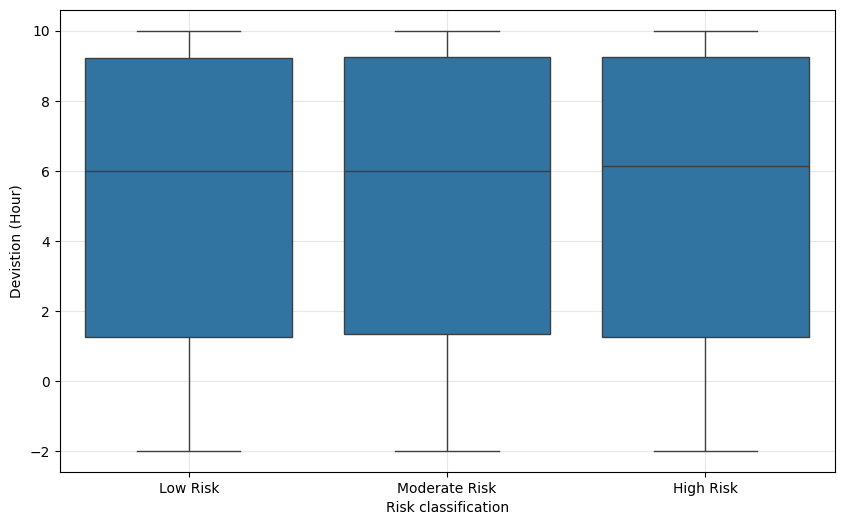

In [45]:
order = ['Low Risk', 'Moderate Risk', 'High Risk']
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='risk_classification',y='delivery_time_deviation',order=order)
plt.xlabel("Risk classification")
plt.ylabel("Devistion (Hour)")
plt.grid(True,alpha=0.3)
plt.show()

In [46]:
df.groupby('risk_classification')['delivery_time_deviation'].mean().round(3)

risk_classification
High Risk        5.184
Low Risk         5.118
Moderate Risk    5.184
Name: delivery_time_deviation, dtype: float64

14 Correlation Heatmap

In [47]:
df

,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,...,delivery_time_deviation,time_diff_hours,is_early,deviation_magnitude,risk_encoded,lat_diff,lon_diff,distance_proxy,hour_of_day,is_weekend
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,...,9.110682,NaN,False,9.110682,1,NaN,NaN,NaN,0,False
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,...,8.175281,1.0,False,8.175281,2,6.867750,40.022585,46.890335,1,False
2,2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,...,1.283594,1.0,False,1.283594,2,3.487179,41.767678,45.254857,2,False
3,2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,...,9.304897,1.0,False,9.304897,2,6.628583,5.078695,11.707277,3,False
4,2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,...,7.752484,1.0,False,7.752484,2,6.647943,0.178335,6.826278,4,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32060,2024-08-28 20:00:00,48.496665,-104.031158,5.421806,4.394370,0.192421,127.684977,3.607803,0.208643,0.992997,...,5.506049,1.0,False,5.506049,2,12.432274,26.516391,38.948666,20,False
32061,2024-08-28 21:00:00,34.670137,-89.893091,10.624778,2.700635,8.736143,84.638889,1.218165,0.472389,0.946031,...,-1.876938,1.0,True,1.876938,2,13.826527,14.138067,27.964594,21,False
32062,2024-08-28 22:00:00,42.963338,-82.149873,5.071596,0.485288,7.420200,48.500920,4.999149,0.064366,0.437687,...,9.790219,1.0,False,9.790219,1,8.293200,7.743219,16.036419,22,False
32063,2024-08-28 23:00:00,32.082410,-70.070154,5.000000,4.759411,0.932050,972.437425,0.505242,0.250949,0.517051,...,9.956879,1.0,False,9.956879,2,10.880928,12.079719,22.960646,23,False


In [48]:
df.columns

Index(['timestamp', 'vehicle_gps_latitude', 'vehicle_gps_longitude',
       'fuel_consumption_rate', 'eta_variation_hours',
       'traffic_congestion_level', 'warehouse_inventory_level',
       'loading_unloading_time', 'handling_equipment_availability',
       'order_fulfillment_status', 'weather_condition_severity',
       'port_congestion_level', 'shipping_costs', 'supplier_reliability_score',
       'lead_time_days', 'historical_demand', 'iot_temperature',
       'cargo_condition_status', 'route_risk_level', 'customs_clearance_time',
       'driver_behavior_score', 'fatigue_monitoring_score',
       'disruption_likelihood_score', 'delay_probability',
       'risk_classification', 'delivery_time_deviation', 'time_diff_hours',
       'is_early', 'deviation_magnitude', 'risk_encoded', 'lat_diff',
       'lon_diff', 'distance_proxy', 'hour_of_day', 'is_weekend'],
      dtype='str')

In [49]:

key_features = [
    'traffic_congestion_level',
    'weather_condition_severity',
    'port_congestion_level',
    'route_risk_level',
    'disruption_likelihood_score',
    'delay_probability'
]
corr_matrix=df[key_features].corr().round(3)

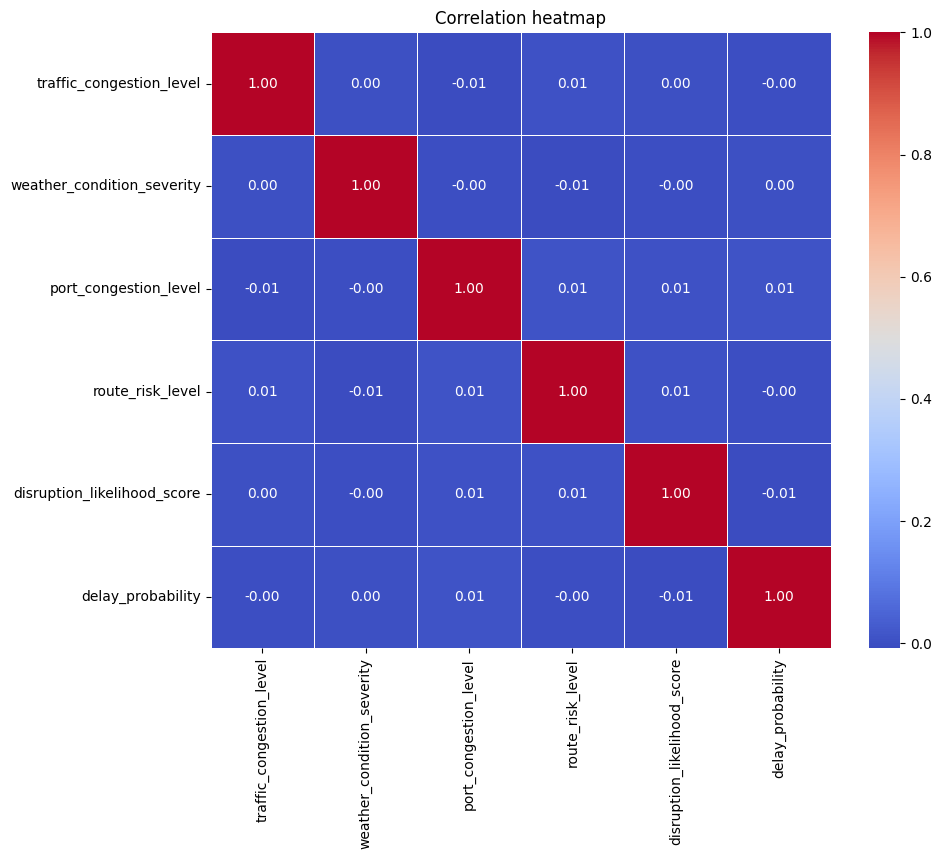

In [50]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.6)
plt.title("Correlation heatmap")
plt.show()

In [51]:
# top correlation with delay probablity
print(corr_matrix['delay_probability'].sort_values(ascending=False))

delay_probability              1.000
port_congestion_level          0.009
weather_condition_severity     0.002
route_risk_level              -0.003
traffic_congestion_level      -0.004
disruption_likelihood_score   -0.008
Name: delay_probability, dtype: float64


15.  Monthly Trend Analysis

In [52]:
monthly_delay = (
    df.set_index('timestamp')
      ['delay_probability']
      .resample('ME')
      .mean()
)


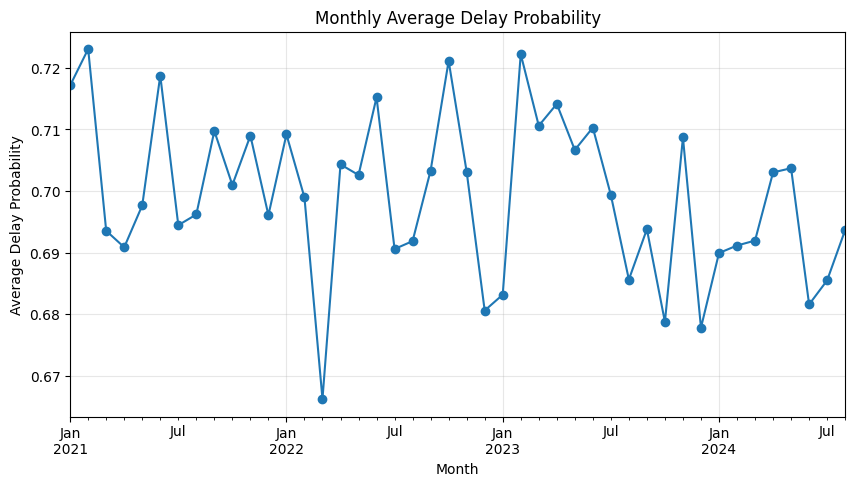

In [53]:
plt.figure(figsize=(10,5))
monthly_delay.plot(marker='o')
plt.title('Monthly Average Delay Probability')
plt.ylabel('Average Delay Probability')
plt.xlabel('Month')
plt.grid(True,alpha=0.3)
plt.show()


In [54]:
monthly_delay.head(6).round(4)

timestamp
2021-01-31    0.7171
2021-02-28    0.7230
2021-03-31    0.6935
2021-04-30    0.6909
2021-05-31    0.6976
2021-06-30    0.7187
Freq: ME, Name: delay_probability, dtype: float64

In [55]:
monthly_delay.tail(6).round(4)

timestamp
2024-03-31    0.6919
2024-04-30    0.7030
2024-05-31    0.7037
2024-06-30    0.6816
2024-07-31    0.6855
2024-08-31    0.6936
Freq: ME, Name: delay_probability, dtype: float64

16. Temperature Bin Analysis

In [56]:
bins=[-20,-5,5,30,50]
labels=[
    'vary cold (-20 to -5)',
    "cold (-5 to 5)",
    'Normal (5 to 30)',
    'Hot (30 to 50)'
]
df['temp_bin']=pd.cut(df['iot_temperature'],
    bins=bins,labels=labels,include_lowest=True)

print(df.groupby('temp_bin',observed=True)
      ['cargo_condition_status'].mean().round(4))

print(df['temp_bin'].value_counts().sort_index())

temp_bin
vary cold (-20 to -5)    0.2984
cold (-5 to 5)           0.2950
Normal (5 to 30)         0.2964
Hot (30 to 50)           0.2955
Name: cargo_condition_status, dtype: float64
temp_bin
vary cold (-20 to -5)    19001
cold (-5 to 5)            4730
Normal (5 to 30)          6042
Hot (30 to 50)            2292
Name: count, dtype: int64


17. Supplier Reliability vs Risk

In [57]:
low_reliability =df[df['supplier_reliability_score']<0.3]
high_reliability=df[df['supplier_reliability_score']>0.8]

print("Low Reliability (<0.3) Risk Distribution (%):")
print(low_reliability['risk_classification']
      .value_counts(normalize=True)
      .mul(100).round(2))


Low Reliability (<0.3) Risk Distribution (%):
risk_classification
High Risk        74.51
Moderate Risk    15.92
Low Risk          9.57
Name: proportion, dtype: float64


In [58]:

print("\nHigh Reliability (>0.8) Risk Distribution (%):")
print(high_reliability['risk_classification']
      .value_counts(normalize=True)
      .mul(100).round(2))


High Reliability (>0.8) Risk Distribution (%):
risk_classification
High Risk        74.53
Moderate Risk    15.76
Low Risk          9.71
Name: proportion, dtype: float64


18.  Fuel Consumption vs Delay Scatter

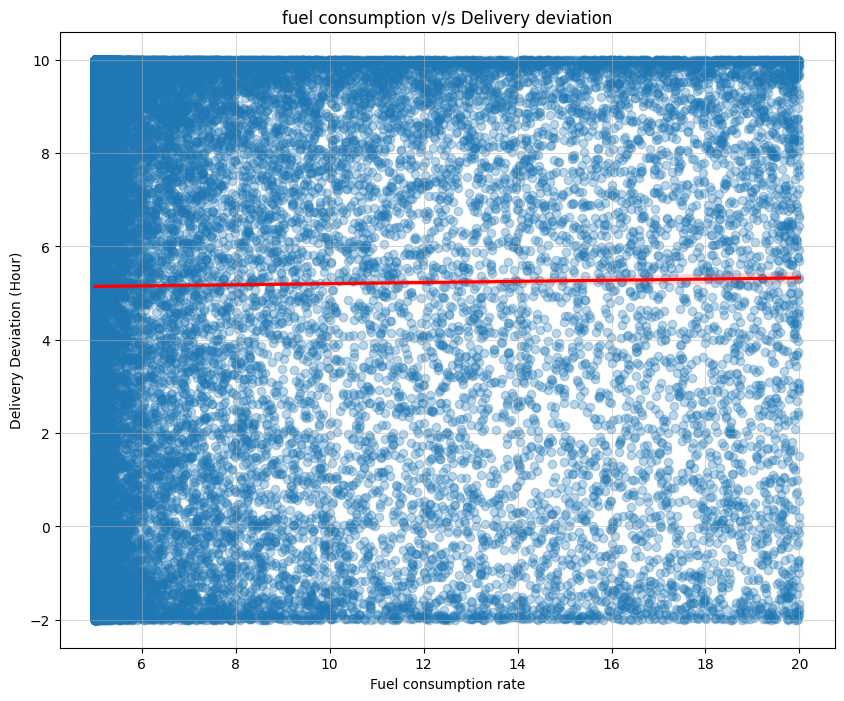

In [59]:
plt.figure(figsize=(10,8))
sns.regplot(data=df,x='fuel_consumption_rate',
        y='delivery_time_deviation',
        scatter_kws={'alpha':0.3},
        line_kws={'color':'red'})
plt.title('fuel consumption v/s Delivery deviation')
plt.xlabel("Fuel consumption rate")
plt.ylabel("Delivery Deviation (Hour)")
plt.grid(True,alpha=0.5)
plt.show()

In [60]:
correlation_value=df['fuel_consumption_rate'].corr(df['delivery_time_deviation'])
print("Correlation value:",round(correlation_value,4))


Correlation value: 0.0125


21.. Stratified Split
Stratification preserves the original class imbalance (75% High Risk).
Without stratification, minority classes could disappear from the test set, leading to misleading evaluation.


In [61]:

features = [
    'traffic_congestion_level', 'weather_condition_severity',
    'port_congestion_level', 'route_risk_level',
    'disruption_likelihood_score', 'supplier_reliability_score',
    'eta_variation_hours', 'fuel_consumption_rate'
]
x=df[features]
y=df['risk_classification']

In [62]:
le=LabelEncoder()
y_encoded=le.fit_transform(y)

In [63]:
x_train,x_test,y_train,y_test=train_test_split(x,y_encoded,test_size=0.25,stratify=y_encoded,random_state=42)

In [64]:
print("Train shape",x_train.shape)
print("Test shape",x_test.shape)

Train shape (24048, 8)
Test shape (8017, 8)


In [65]:
print("\nTest Class Distribution (%):")
print(pd.Series(le.inverse_transform(y_test))
      .value_counts(normalize=True).mul(100).round(2))


Test Class Distribution (%):
High Risk        74.67
Moderate Risk    15.63
Low Risk          9.70
Name: proportion, dtype: float64


22 .Model Training (RF vs GB)


In [66]:
from sklearn.ensemble import GradientBoostingClassifier

In [67]:
rf=RandomForestClassifier(n_estimators=150,random_state=42,n_jobs=-1)
gb=GradientBoostingClassifier(n_estimators=100,random_state=42)

rf.fit(x_train,y_train)
gb.fit(x_train,y_train)

y_pred_rf=rf.predict(x_test)
y_pred_gb=gb.predict(x_test)

print("Rnadom Forest Accuracy:",round(accuracy_score(y_test,y_pred_rf),4))
print("GradientBoosting Accuracy :",round(accuracy_score(y_test,y_pred_gb),4))

print(classification_report(y_test,y_pred_rf,target_names=le.classes_))
print(classification_report(y_test,y_pred_gb,target_names=le.classes_))



Rnadom Forest Accuracy: 1.0
GradientBoosting Accuracy : 1.0
               precision    recall  f1-score   support

    High Risk       1.00      1.00      1.00      5986
     Low Risk       1.00      1.00      1.00       778
Moderate Risk       1.00      1.00      1.00      1253

     accuracy                           1.00      8017
    macro avg       1.00      1.00      1.00      8017
 weighted avg       1.00      1.00      1.00      8017

               precision    recall  f1-score   support

    High Risk       1.00      1.00      1.00      5986
     Low Risk       1.00      1.00      1.00       778
Moderate Risk       1.00      1.00      1.00      1253

     accuracy                           1.00      8017
    macro avg       1.00      1.00      1.00      8017
 weighted avg       1.00      1.00      1.00      8017



23.Class Weight Balancing

In [68]:
rf_plain=RandomForestClassifier(n_estimators=150,random_state=42)
rf_plain.fit(x_train,y_train)

,n_estimators,150
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [69]:
rf_balanced = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    class_weight='balanced'
)
rf_balanced.fit(x_train,y_train)


,n_estimators,150
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [70]:
report_plain=classification_report(
    y_test,
    rf_plain.predict(x_test),
    target_names=le.classes_,
    output_dict=True)

In [71]:
report_balanced=classification_report(
 y_test,
 rf_balanced.predict(x_test),
 target_names=le.classes_,
 output_dict=True   
)

print("High Risk F1 (Without Balanced):",
      round(report_plain['High Risk']['f1-score'], 4))
print("High Risk F1 (With Balanced):",
      round(report_balanced['High Risk']['f1-score'], 4))

print("Low Risk F1 (Without Balanced):",
      round(report_plain['Low Risk']['f1-score'], 4))
print("Low Risk F1 (With Balanced):",
      round(report_balanced['Low Risk']['f1-score'], 4))


High Risk F1 (Without Balanced): 1.0
High Risk F1 (With Balanced): 1.0
Low Risk F1 (Without Balanced): 1.0
Low Risk F1 (With Balanced): 1.0


24.Confusion Matrix


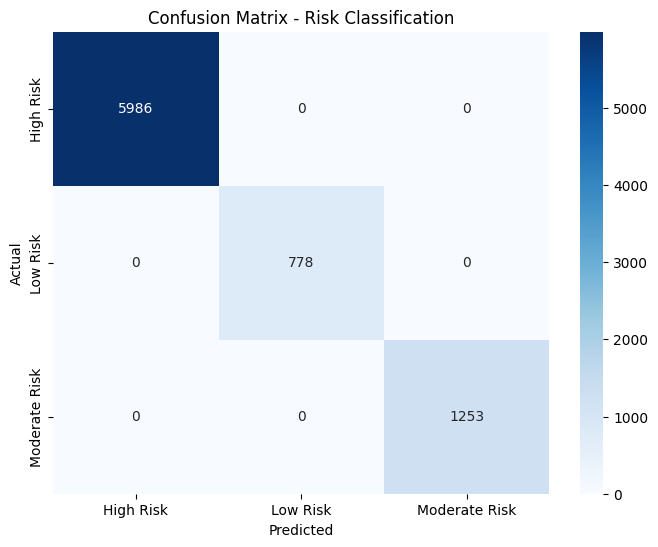

In [72]:
y_pred=rf_balanced.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix - Risk Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

25.Hyperparameter Suggestions


In [73]:
print(classification_report(y_test,y_pred,target_names=le.classes_))


               precision    recall  f1-score   support

    High Risk       1.00      1.00      1.00      5986
     Low Risk       1.00      1.00      1.00       778
Moderate Risk       1.00      1.00      1.00      1253

     accuracy                           1.00      8017
    macro avg       1.00      1.00      1.00      8017
 weighted avg       1.00      1.00      1.00      8017



26 Annual Late Delivery Cost

In [74]:

late_percentage = (df['delivery_time_deviation'] > 0).mean()
monthly_shipments = 10000
cost_per_late = 12000

monthly_cost=monthly_shipments*late_percentage*cost_per_late
annual_cost_score=(monthly_cost*12)/10000000

print(f"Late Deliveries:{late_percentage*100 :.2f}%")
print(f"Estimated Annual  Loss:{annual_cost_score :.2f}crore")

Late Deliveries:82.09%
Estimated Annual  Loss:118.21crore


28 .Annual Saving Calculation

In [75]:
high_risk_perc=0.7469
recall=0.88

detected_high_risk =monthly_shipments* high_risk_perc *recall
hours_saved =5.18-2.5
cost_per_hour=12000/5.18

monthly_saving=detected_high_risk*hours_saved*cost_per_hour
annual_saving_score=(monthly_saving*12)/10000000

print(f"Estimated Annual saving :{annual_saving_score:.2f} crore")

Estimated Annual saving :48.97 crore


29. ROI Calculation

In [76]:
model_cost =40000000 
realistic_saving=annual_saving_score *10000000*0.65

net_benefit=realistic_saving-model_cost
roi_percent=(net_benefit/model_cost)*100

print(f"Realistic Annual Saving: ₹ {realistic_saving/10000000:.2f} crore")
print(f"First-Year ROI: {roi_percent:.0f}%")

Realistic Annual Saving: ₹ 31.83 crore
First-Year ROI: 696%


In [77]:
import pickle

with open('le.pkl', 'wb') as file:
    pickle.dump(le, file)

with open('rf.pkl', 'wb') as file:
    pickle.dump(rf, file)